In [ ]:
# Реализовать генератор пользовательских данных для решения задачи подсчета количества клеток крови на изображениях клеток крови.
# Изучите набор данных, располагающийся в архиве blood_cells.
# Выполните "нарезку" изображений. Сохраните в отдельные папки изображения фона и изображения клеток крови.
# Реализуйте генератор данных: снимков клеток крови. 

# Фон изображения формируется из набора патчей.
# 1) патчи, вырезанные из исходного набора данных 
# 2) искусственно сформированные патчи (равномерная заливка фона из диапазона допустимых значений цвета)

# Патчи для клеток крови:
# 1) патчи, вырезанные из исходного набора данных
# 2) искусствено сгенерированные окружности с заливкой из допустимого набора знаений цвета

# для blending-задачи (объединения изображения фона и изображений объектов) применять: https://learnopencv.com/seamless-cloning-using-opencv-python-cpp/

##########
# Основные этапы генерации:
# 1. Выбор и формирование патчей фона, их препроцессинг. Формирование(комбинирование) фона из набора патчей. Постпроцессинг результирующего фона.
# 2. Выбор количества клеток крови, выбор метоположения клекток, выбор/формирование клеток, совмещение клеток на фоновом изображении
# 3. Постпроцессинг. Аугментация и зашумление. 
# "выбор" чаще всего означает генерацию псевдослучайного числа при помощи генератора в допустимом диапазоне.

Для создания пользовательского датасета class должен переопределить следующие методы: 
def __init__(self, param1, param2, param3...):
 вызывается один раз при создании объекта класса-наследника Dataset object. Сохраняются директории-пути к файлам и аннотациям, методы аугмпентации  пользовательских данных. 
def __len__(self):
Возвращаеет Количество экземпляров выборки в пользовательском датасете
def __getitem__(self, idx):
Загружает и возвращает экзмляр данных по индексу idx

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as v2
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.ToTensor()
)

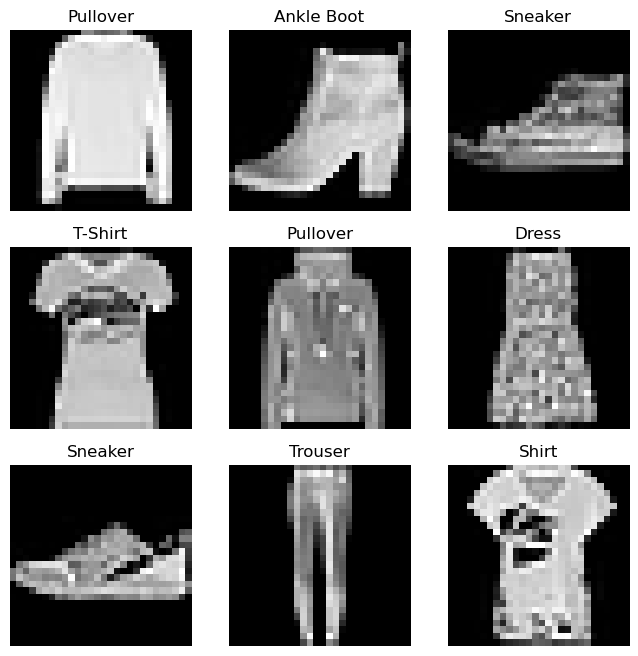

In [2]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()


In [3]:
import os
import random
import numpy as np
from PIL import Image

DATASET_ROOT = '../02_Лекция_Мат_Наборы_данных/blood_cells_dataset/BCCD Dataset with mask'
ORIG_DIR = os.path.join(DATASET_ROOT, 'train', 'original')
MASK_DIR = os.path.join(DATASET_ROOT, 'train', 'mask')
PATCHES_DIR = '../my_patches'
PATCH_SIZE = 64
N_IMAGES_TO_LOAD = 30

bg_dir = os.path.join(PATCHES_DIR, 'background')
cell_dir = os.path.join(PATCHES_DIR, 'cells')
os.makedirs(bg_dir, exist_ok=True)
os.makedirs(cell_dir, exist_ok=True)

bg_count = 0
cell_count = 0

all_files = [f for f in os.listdir(ORIG_DIR) if f.endswith('.png')]
random.shuffle(all_files)
for fname in all_files[:N_IMAGES_TO_LOAD]:
    try:
        img = np.array(Image.open(os.path.join(ORIG_DIR, fname)).convert('RGB'))
        mask = np.array(Image.open(os.path.join(MASK_DIR, fname)).convert('L'))
    except Exception:
        continue
    h, w = img.shape[:2]
    ps = PATCH_SIZE
    for _ in range(4):
        x = random.randint(0, w - ps)
        y = random.randint(0, h - ps)
        patch = img[y:y+ps, x:x+ps]
        patch_mask = mask[y:y+ps, x:x+ps]
        if patch_mask.mean() < 15:
            Image.fromarray(patch).save(os.path.join(bg_dir, f'bg_{bg_count:04d}.png'))
            bg_count += 1
        elif patch_mask.mean() > 120:
            Image.fromarray(patch).save(os.path.join(cell_dir, f'cell_{cell_count:04d}.png'))
            cell_count += 1

print(f'Background patches saved: {bg_count}  →  {bg_dir}')
print(f'Cell patches saved:       {cell_count}  →  {cell_dir}')


Background patches saved: 53  →  ../my_patches\background
Cell patches saved:       38  →  ../my_patches\cells


In [5]:
from __future__ import annotations

import numpy as np
import cv2
import os
import random
import torch
from torch.utils.data import Dataset
from typing import Tuple, List
from PIL import Image


class BloodCellCountDataset(Dataset):
    """Synthetic blood smear dataset for cell counting"""

    def __init__(
        self,
        patches_dir: str,
        img_size: Tuple[int, int],
        dataset_size: int,
        max_cells: int = 8,
        cell_size_range: Tuple[int, int] = (18, 45),
    ):
        self.img_size = img_size
        self.dataset_size = dataset_size
        self.max_cells = max_cells
        self.cell_size_range = cell_size_range

        self.bg_patches: List[np.ndarray] = []
        self.cell_patches: List[np.ndarray] = []
        self._load_patches_from_dir(patches_dir)

    def _load_patches_from_dir(self, patches_dir: str):
        bg_dir = os.path.join(patches_dir, 'background')
        cell_dir = os.path.join(patches_dir, 'cells')
        for fname in sorted(os.listdir(bg_dir)):
            img = np.array(Image.open(os.path.join(bg_dir, fname)).convert('RGB'))
            self.bg_patches.append(img)
        for fname in sorted(os.listdir(cell_dir)):
            img = np.array(Image.open(os.path.join(cell_dir, fname)).convert('RGB'))
            self.cell_patches.append(img)
        print(f'Loaded {len(self.bg_patches)} background patches, {len(self.cell_patches)} cell patches')

    def __len__(self) -> int:
        return self.dataset_size

    def _make_background(self) -> np.ndarray:
        if self.bg_patches and random.random() < 0.65:
            patch = random.choice(self.bg_patches)
            bg = cv2.resize(patch, (self.img_size[1], self.img_size[0]))
        else:
            r = random.randint(205, 240)
            g = random.randint(170, 210)
            b = random.randint(170, 210)
            bg = np.full((self.img_size[0], self.img_size[1], 3), [r, g, b], dtype=np.uint8)
            noise = np.random.randint(-12, 12, bg.shape, dtype=np.int16)
            bg = np.clip(bg.astype(np.int16) + noise, 0, 255).astype(np.uint8)
        return bg

    def _make_cell(self, size: int) -> np.ndarray:
        if self.cell_patches and random.random() < 0.55:
            patch = random.choice(self.cell_patches)
            return cv2.resize(patch, (size, size))
        cell = np.zeros((size, size, 3), dtype=np.uint8)
        r = random.randint(145, 205)
        g = random.randint(45, 90)
        b = random.randint(45, 90)
        cv2.circle(cell, (size // 2, size // 2), size // 2 - 1, (r, g, b), -1)
        cv2.circle(cell, (size // 2, size // 2), size // 4, (max(r - 45, 0), max(g - 20, 0), max(b - 20, 0)), -1)
        return cell

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        img = self._make_background()
        num_cells = random.randint(0, self.max_cells)

        for _ in range(num_cells):
            size = random.randint(self.cell_size_range[0], self.cell_size_range[1])
            cell = self._make_cell(size)
            x = random.randint(0, self.img_size[1] - size)
            y = random.randint(0, self.img_size[0] - size)
            circle_mask = np.zeros((size, size), dtype=np.uint8)
            cv2.circle(circle_mask, (size // 2, size // 2), size // 2 - 1, 255, -1)
            alpha = circle_mask[:, :, np.newaxis] / 255.0
            roi = img[y:y+size, x:x+size]
            img[y:y+size, x:x+size] = (alpha * cell + (1.0 - alpha) * roi).astype(np.uint8)

        img_tensor = torch.FloatTensor(img.astype(np.float32) / 255.0)
        return img_tensor, num_cells


In [8]:
import csv

DATASET_DIR = '../my_blood_dataset'
DATASET_SIZE = 1000
IMG_SIZE = (256, 256)

os.makedirs(DATASET_DIR, exist_ok=True)

blood_dataset = BloodCellCountDataset(
    patches_dir='../my_patches',
    img_size=IMG_SIZE,
    dataset_size=DATASET_SIZE,
    max_cells=8,
    cell_size_range=(18, 45),
)

labels = []
for idx in range(len(blood_dataset)):
    img_tensor, cell_count = blood_dataset[idx]
    img_np = (img_tensor.numpy() * 255).astype(np.uint8)
    fname = f'{idx:04d}.png'
    Image.fromarray(img_np).save(os.path.join(DATASET_DIR, fname))
    labels.append((fname, cell_count))

csv_path = os.path.join(DATASET_DIR, 'labels.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['filename', 'cell_count'])
    writer.writerows(labels)

print(f'Saved {len(labels)} images  →  {DATASET_DIR}')
print(f'Labels saved  →  {csv_path}')


Loaded 53 background patches, 44 cell patches
Saved 1000 images  →  ../my_blood_dataset
Labels saved  →  ../my_blood_dataset\labels.csv


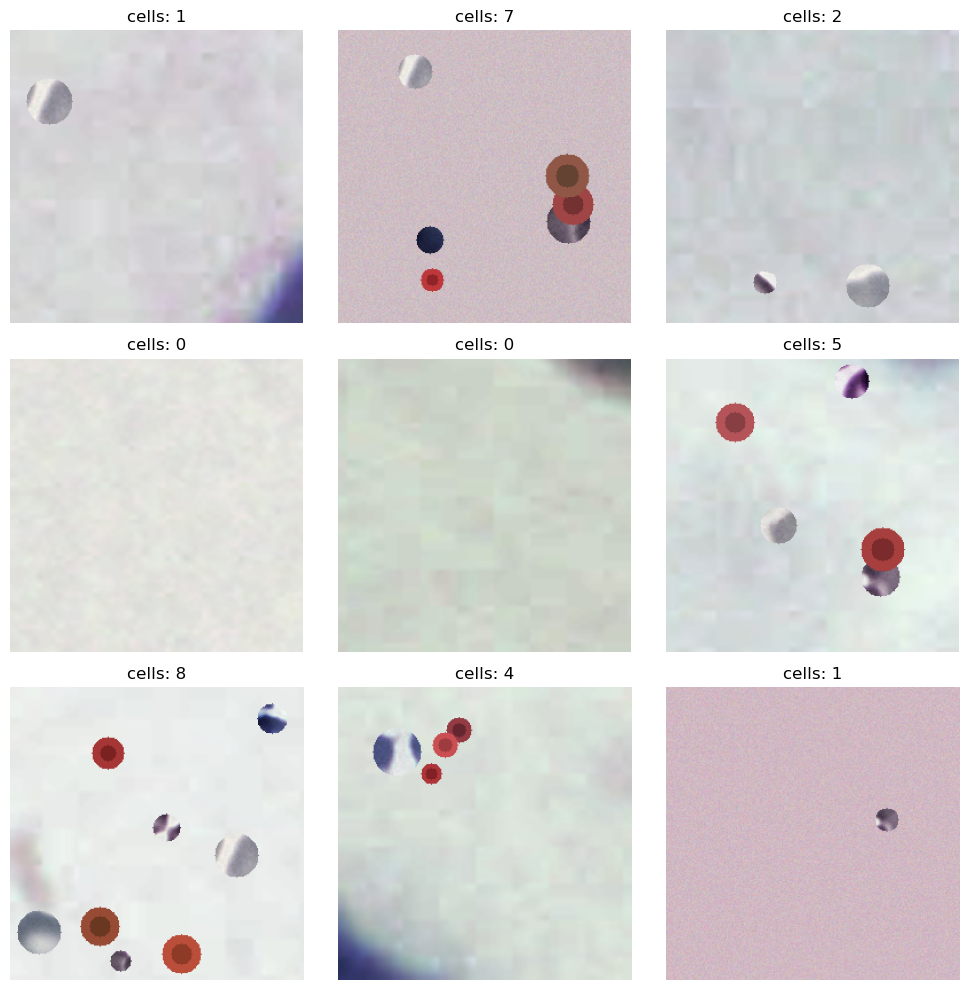

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

labels_df = pd.read_csv(os.path.join(DATASET_DIR, 'labels.csv'))

figure = plt.figure(figsize=(10, 10))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    row = labels_df.sample(1).iloc[0]
    img = np.array(Image.open(os.path.join(DATASET_DIR, row['filename'])))
    figure.add_subplot(rows, cols, i)
    plt.title(f'cells: {int(row["cell_count"])}')
    plt.axis('off')
    plt.imshow(img)
plt.tight_layout()
plt.show()
